# Análisis TIR y VAN
Carga de librerías y definición de parámetros, escenarios y matrices de resultados.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# 1. Preparación de Datos
tipologias = ["Unif. seg", "Unif. conj", "Pluri U2C", "Pluri U4C"]
escenarios = ["Conservador", "Base", "Optimista"]

# Colores institucionales para análisis financiero
azules = ["#c6dbef", "#6baed6", "#2171b5"] # Venta
rojos  = ["#fcbba1", "#fb6a4a", "#cb181d"] # Alquiler

tir_venta = np.array([
    [12.81, 21.26, 31.60],
    [11.88, 19.85, 29.75],
    [15.43, 22.66, 31.09],
    [10.65, 15.88, 22.21],
])

tir_alquiler = np.array([
    [-2.56, -0.09, 2.41],
    [-2.34,  0.15, 2.67],
    [ 2.39,  4.98, 7.51],
    [ 2.08,  4.70, 7.27],
])


van_venta = np.array([
    [0.21, 0.64, 0.99],
    [0.18, 0.72, 1.16],
    [0.79, 1.44, 1.97],
    [0.16, 1.14, 1.94]
])

van_alquiler = np.array([
    [-5.03, -4.51, -3.83],
    [-5.99, -5.34, -4.48],
    [-3.91, -2.90, -1.65],
    [-5.65, -4.26, -2.51]
])



## TIR por escenarios
Comparativa de TIR para venta y alquiler por tipología, diferenciando escenarios.

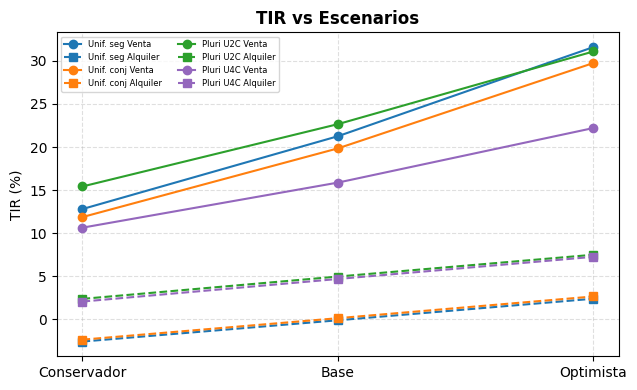

In [2]:
# TIR vs Escenarios
fig, ax1 = plt.subplots(figsize=(6.5, 4))

esc_x = ["Conservador", "Base", "Optimista"]
x = np.arange(len(esc_x))
colores_tip = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

for i, t in enumerate(tipologias):
    ax1.plot(x, tir_venta[i, :], marker='o', linestyle='-',
             color=colores_tip[i], label=f"{t} Venta")
    ax1.plot(x, tir_alquiler[i, :], marker='s', linestyle='--',
             color=colores_tip[i], label=f"{t} Alquiler")

ax1.set_title("TIR vs Escenarios", fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(esc_x)
ax1.set_ylabel("TIR (%)")
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

## Eficiencia TIR vs VAN
Relación TIR-VAN para todos los escenarios, con doble leyenda por color y marcador.

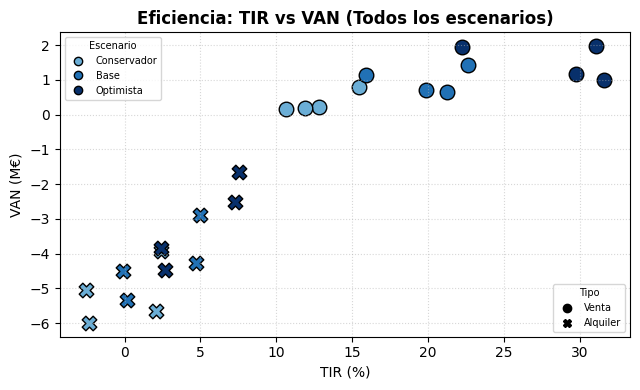

In [3]:
# Eficiencia: TIR vs VAN (Todos los escenarios)
fig, ax2 = plt.subplots(figsize=(6.5, 4))

colores_esc = ["#6baed6", "#2171b5", "#08306b"]
markers = {"Venta": "o", "Alquiler": "X"}

for j, esc in enumerate(escenarios):
    ax2.scatter(tir_venta[:, j], van_venta[:, j],
                s=110, marker=markers["Venta"], color=colores_esc[j],
                edgecolors='k')
    ax2.scatter(tir_alquiler[:, j], van_alquiler[:, j],
                s=110, marker=markers["Alquiler"], color=colores_esc[j],
                edgecolors='k')

ax2.set_title("Eficiencia: TIR vs VAN (Todos los escenarios)", fontweight='bold')
ax2.set_xlabel("TIR (%)")
ax2.set_ylabel("VAN (M€)")
ax2.grid(True, linestyle=':', alpha=0.5)

legend_esc = ax2.legend(
    handles=[Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                    markeredgecolor='k', markersize=6, linestyle='')
             for c in colores_esc],
    labels=escenarios, title="Escenario", fontsize=7, title_fontsize=7,
    loc='upper left'
 )
ax2.add_artist(legend_esc)

ax2.legend(
    handles=[
        Line2D([0], [0], marker='o', color='black', linestyle='', label='Venta'),
        Line2D([0], [0], marker='X', color='black', linestyle='', label='Alquiler')
    ],
    title="Tipo", fontsize=7, title_fontsize=7, loc='lower right'
)

plt.tight_layout()
plt.show()

## VAN por tipología
Comparación de VAN de venta y alquiler en subplots con el mismo ancho.

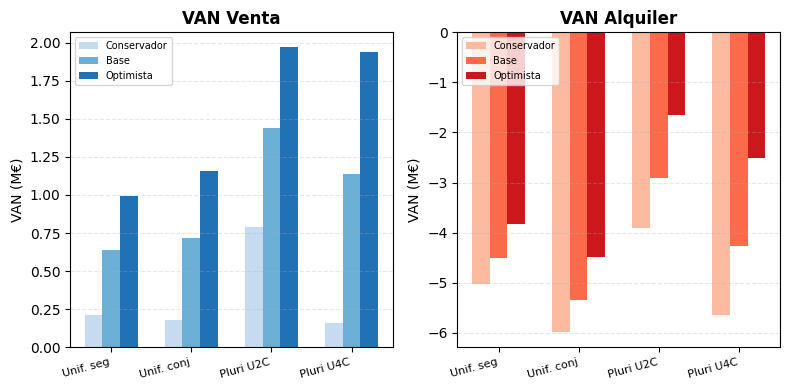

In [4]:
# VAN: Venta y Alquiler (1:1)
fig = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1])
ax3 = fig.add_subplot(gs[0, 0])
ax4 = fig.add_subplot(gs[0, 1])

x_tip = np.arange(len(tipologias))
width = 0.22

for i in range(3):
    ax3.bar(x_tip + i * width, van_venta[:, i],
            width, label=escenarios[i], color=azules[i])

ax3.set_title("VAN Venta", fontweight='bold')
ax3.set_xticks(x_tip + width)
ax3.set_xticklabels(tipologias, rotation=15, ha='right', fontsize=8)
ax3.set_ylabel("VAN (M€)")
ax3.grid(axis='y', linestyle='--', alpha=0.3)
ax3.legend(fontsize=7, loc='upper left')

for i in range(3):
    ax4.bar(x_tip + i * width, van_alquiler[:, i],
            width, label=escenarios[i], color=rojos[i])

ax4.set_title("VAN Alquiler", fontweight='bold')
ax4.set_xticks(x_tip + width)
ax4.set_xticklabels(tipologias, rotation=15, ha='right', fontsize=8)
ax4.set_ylabel("VAN (M€)")
ax4.grid(axis='y', linestyle='--', alpha=0.3)
ax4.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

## Ranking de creación de valor
Ranking por VAN (escenario base) con etiquetas fuera de las barras.

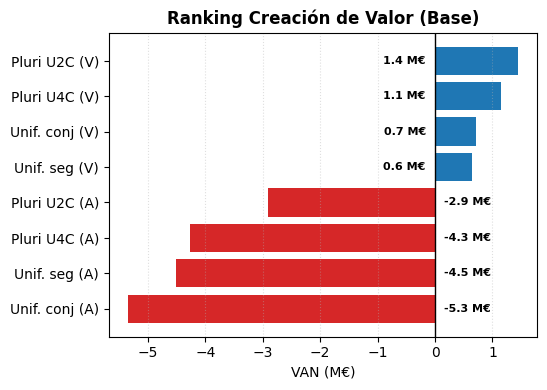

In [5]:
# Ranking Creación de Valor (Base)
fig, ax5 = plt.subplots(figsize=(7, 4))

total_van = np.concatenate([van_venta[:, 1], van_alquiler[:, 1]])
labels = [f"{t} (V)" for t in tipologias] + [f"{t} (A)" for t in tipologias]

idx = np.argsort(total_van)
vals = total_van[idx]
labs = np.array(labels)[idx]

colors = ["#1f77b4" if v > 0 else "#d62728" for v in vals]
bars = ax5.barh(labs, vals, color=colors)

ax5.axvline(0, color='black', linewidth=1)
ax5.set_title("Ranking Creación de Valor (Base)", fontweight='bold')
ax5.set_xlabel("VAN (M€)")
ax5.grid(axis='x', linestyle=':', alpha=0.4)

max_abs = np.max(np.abs(vals))
gap = max_abs * 0.03

for bar in bars:
    w = bar.get_width()
    x_text = -gap if w > 0 else gap
    ha = 'right' if w > 0 else 'left'
    ax5.text(x_text, bar.get_y() + bar.get_height()/2,
             f"{w:.1f} M€",
             ha=ha, va='center', color='black', fontsize=8, fontweight='bold')

plt.tight_layout()

pos = ax5.get_position()
new_width = pos.width * 0.75
new_x0 = pos.x0 + (pos.width - new_width)
ax5.set_position([new_x0, pos.y0, new_width, pos.height])

plt.show()

## Ranking TIR (escenario base)
Ranking de TIR en escenario base, con etiquetas externas por signo.

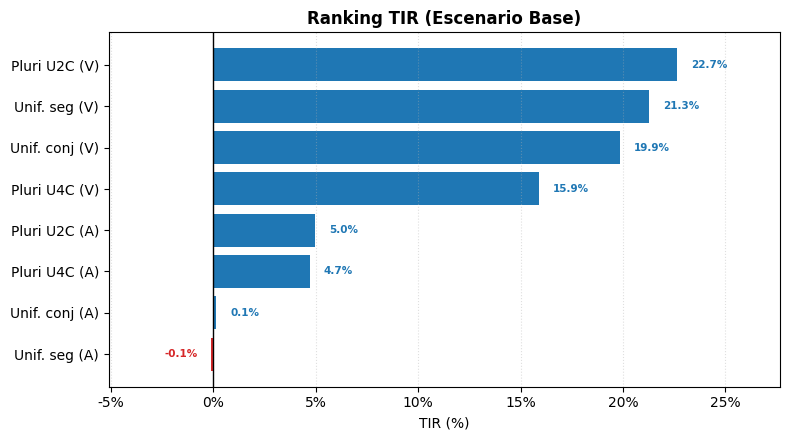

In [6]:
# Ranking TIR (Base)
fig, ax = plt.subplots(figsize=(8, 4.5))

tir_base = np.concatenate([tir_venta[:, 1], tir_alquiler[:, 1]])
labels_tir = [f"{t} (V)" for t in tipologias] + [f"{t} (A)" for t in tipologias]

idx = np.argsort(tir_base)
vals = tir_base[idx]
labs = np.array(labels_tir)[idx]

colors = ["#1f77b4" if v > 0 else "#d62728" for v in vals]
ax.barh(labs, vals, color=colors)

ax.axvline(0, color='black', linewidth=1)
ax.set_title("Ranking TIR (Escenario Base)", fontweight='bold')
ax.set_xlabel("TIR (%)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.grid(axis='x', linestyle=':', alpha=0.4)

max_abs = np.max(np.abs(vals))
gap = max_abs * 0.03

for v, bar_y in zip(vals, ax.patches):
    y_center = bar_y.get_y() + bar_y.get_height() / 2
    if v >= 0:
        ax.text(v + gap, y_center, f"{v:.1f}%",
                ha='left', va='center', fontsize=7.5, fontweight='bold', color='#1f77b4')
    else:
        ax.text(v - gap, y_center, f"{v:.1f}%",
                ha='right', va='center', fontsize=7.5, fontweight='bold', color='#d62728')

ax.margins(x=0.22)
plt.tight_layout()
plt.show()

## Ranking combinado VAN y TIR
Comparativa combinada con barras de VAN y diamantes de TIR sobre doble eje.

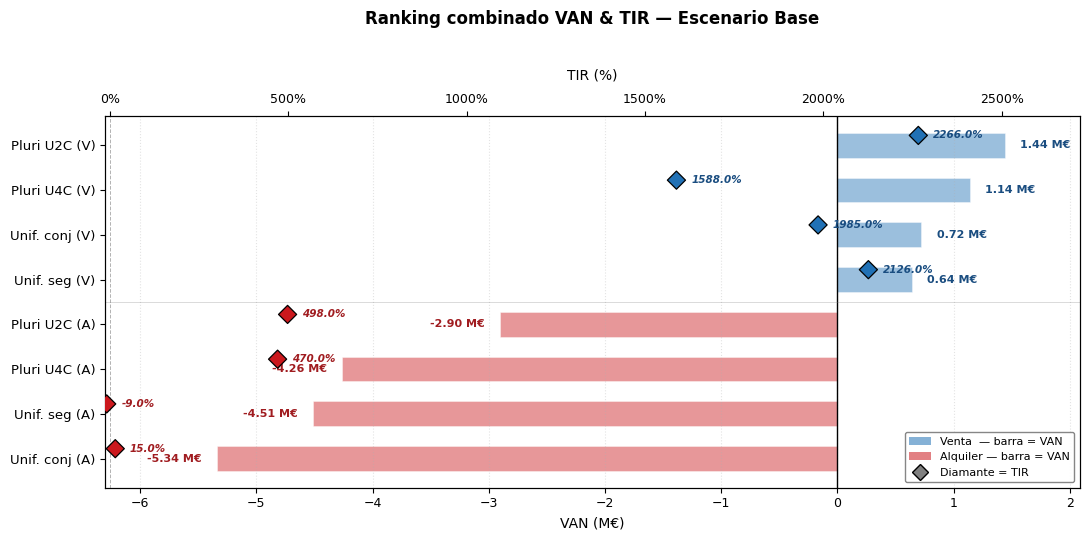

In [ ]:
# Ranking combinado VAN + TIR (Base)
fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax2 = ax1.twiny()  # top x-axis for TIR

# ── datos ──────────────────────────────────────────────────────────────────
van_b  = np.concatenate([van_venta[:, 1],       van_alquiler[:, 1]])
tir_b  = np.concatenate([tir_venta[:, 1] * 100, tir_alquiler[:, 1] * 100])
labs_c = [f"{t} (V)" for t in tipologias] + [f"{t} (A)" for t in tipologias]
cols_c = ["#2171b5"] * 4 + ["#cb181d"] * 4

idx    = np.argsort(van_b)
van_s  = van_b[idx]
tir_s  = tir_b[idx]
labs_s = np.array(labs_c)[idx]
col_s  = np.array(cols_c)[idx]
y      = np.arange(len(labs_s))

# ── barras VAN (eje inferior) ───────────────────────────────────────────────
ax1.barh(y, van_s, color=col_s, alpha=0.45, height=0.55,
         edgecolor='white', linewidth=0.6)
ax1.axvline(0, color='black', linewidth=1)
ax1.set_xlabel("VAN (M€)", fontsize=10)
ax1.tick_params(axis='x', labelsize=9)

# Etiquetas VAN: alejadas un poco más para que no choquen con los diamantes
van_range = np.max(np.abs(van_s))
van_gap   = van_range * 0.025
for i, v in enumerate(van_s):
    color_lbl = '#1a4d80' if v >= 0 else '#a01c20'
    if v >= 0:
        ax1.text(v + van_gap, y[i], f"{v:.2f} M€",
                 va='center', ha='left', fontsize=8, fontweight='bold', color=color_lbl)
    else:
        ax1.text(v - van_gap, y[i], f"{v:.2f} M€",
                 va='center', ha='right', fontsize=8, fontweight='bold', color=color_lbl)

# ── diamantes TIR (eje superior) ────────────────────────────────────────────
# Desplazamos los diamantes ligeramente HACIA ABAJO del centro de la fila
# para que no solapen con la etiqueta VAN
y_diam = y + 0.22
ax2.scatter(tir_s, y_diam, s=85, color=col_s, edgecolors='black',
            linewidths=0.9, zorder=5, marker='D')
ax2.axvline(0, color='gray', linewidth=0.7, linestyle='--', zorder=1, alpha=0.6)
ax2.set_xlabel("TIR (%)", labelpad=10, fontsize=10)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax2.tick_params(axis='x', labelsize=9)

# Etiquetas TIR: justo a la derecha del diamante, en cursiva para diferenciar
tir_range = np.max(np.abs(tir_s)) - np.min(tir_s)
tir_gap   = tir_range * 0.018
for i, t in enumerate(tir_s):
    color_lbl = '#1a4d80' if i in np.where(np.array([c == "#2171b5" for c in col_s]))[0] else '#a01c20'
    ax2.text(t + tir_gap, y_diam[i], f"{t:.1f}%",
             va='center', ha='left', fontsize=7.5, color=color_lbl,
             fontstyle='italic', fontweight='bold')

# ── ejes y título ────────────────────────────────────────────────────────────
ax1.set_yticks(y)
ax1.set_yticklabels(labs_s, fontsize=9.5)
ax1.set_title("Ranking combinado VAN & TIR — Escenario Base",
              fontweight='bold', pad=32)
ax1.grid(axis='x', linestyle=':', alpha=0.35)

# Márgenes amplios para acomodar etiquetas
ax1.set_xlim(van_s.min() * 1.18, van_s.max() * 1.45)
ax2.set_xlim(min(tir_s.min() * 1.5, -3), tir_s.max() * 1.20)

# Línea horizontal sutil que separa Venta de Alquiler
# (busca la transición V -> A en las etiquetas ordenadas)
for i in range(len(labs_s) - 1):
    if "(V)" in labs_s[i] and "(A)" in labs_s[i + 1]:
        ax1.axhline(i + 0.5, color='gray', linewidth=0.5, linestyle='-', alpha=0.4)
        break
    if "(A)" in labs_s[i] and "(V)" in labs_s[i + 1]:
        ax1.axhline(i + 0.5, color='gray', linewidth=0.5, linestyle='-', alpha=0.4)
        break

# ── leyenda ──────────────────────────────────────────────────────────────────
legend_elems = [
    Patch(facecolor='#2171b5', alpha=0.55, label='Venta  — barra = VAN'),
    Patch(facecolor='#cb181d', alpha=0.55, label='Alquiler — barra = VAN'),
    Line2D([0], [0], marker='D', color='none', markerfacecolor='gray',
           markeredgecolor='black', markersize=8, label='Diamante = TIR'),
]
ax1.legend(handles=legend_elems, fontsize=8, loc='lower right',
           framealpha=0.95, edgecolor='gray')

plt.tight_layout()
plt.show()

## Ranking doble panel
Comparación paralela: ordenado por VAN (izquierda) y por TIR (derecha).

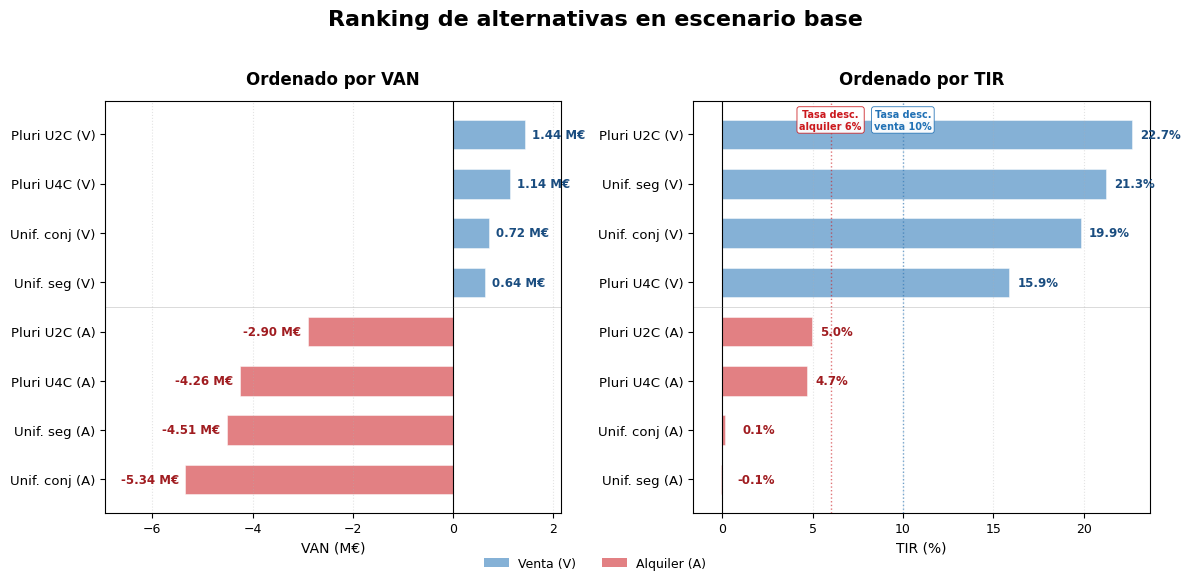

In [ ]:
# ── construcción de listas combinadas (escenario base = índice 1) ──────────
van_b  = np.concatenate([van_venta[:, 1],  van_alquiler[:, 1]])
tir_b  = np.concatenate([tir_venta[:, 1],  tir_alquiler[:, 1]])
labs_c = [f"{t} (V)" for t in tipologias] + [f"{t} (A)" for t in tipologias]
cols_c = np.array(["#2171b5"] * 4 + ["#cb181d"] * 4)

# ── figura ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# ============================================================
# PANEL IZQUIERDO: ordenado por VAN
# ============================================================
# Ordena por VAN y mantiene etiquetas/colores sincronizados
idx_v  = np.argsort(van_b)
van_s  = van_b[idx_v]
labs_v = np.array(labs_c)[idx_v]
cols_v = cols_c[idx_v]
y      = np.arange(len(labs_v))

# Barras horizontales con línea de cero
ax1.barh(y, van_s, color=cols_v, alpha=0.55, height=0.6,
         edgecolor='white', linewidth=0.6)
ax1.axvline(0, color='black', linewidth=0.8)

# Etiquetas con desplazamiento para evitar solapamiento
van_gap = np.max(np.abs(van_s)) * 0.025
for i, v in enumerate(van_s):
    color_lbl = '#1a4d80' if v >= 0 else '#a01c20'
    if v >= 0:
        ax1.text(v + van_gap, y[i], f"{v:.2f} M€",
                 va='center', ha='left', fontsize=8.5,
                 fontweight='bold', color=color_lbl)
    else:
        ax1.text(v - van_gap, y[i], f"{v:.2f} M€",
                 va='center', ha='right', fontsize=8.5,
                 fontweight='bold', color=color_lbl)

# Estilo de ejes
ax1.set_yticks(y)
ax1.set_yticklabels(labs_v, fontsize=9.5)
ax1.set_xlabel("VAN (M€)", fontsize=10)
ax1.set_title("Ordenado por VAN", fontsize=12, fontweight='bold', pad=12)
ax1.tick_params(axis='x', labelsize=9)
ax1.grid(axis='x', linestyle=':', alpha=0.35)
ax1.set_xlim(van_s.min() * 1.30, van_s.max() * 1.50)

# Línea separadora V/A
for i in range(len(labs_v) - 1):
    if (("(V)" in labs_v[i] and "(A)" in labs_v[i + 1]) or
        ("(A)" in labs_v[i] and "(V)" in labs_v[i + 1])):
        ax1.axhline(i + 0.5, color='gray', linewidth=0.5,
                    linestyle='-', alpha=0.4)

# ============================================================
# PANEL DERECHO: ordenado por TIR
# ============================================================
# Ordena por TIR y mantiene etiquetas/colores sincronizados
idx_t  = np.argsort(tir_b)
tir_s  = tir_b[idx_t]
labs_t = np.array(labs_c)[idx_t]
cols_t = cols_c[idx_t]
y      = np.arange(len(labs_t))

# Barras horizontales con línea de cero
ax2.barh(y, tir_s, color=cols_t, alpha=0.55, height=0.6,
         edgecolor='white', linewidth=0.6)
ax2.axvline(0, color='black', linewidth=0.8)

# Líneas de referencia para tasas de descuento
ax2.axvline(10, color='#2171b5', linewidth=1.0, linestyle=':', alpha=0.6)
ax2.axvline(6,  color='#cb181d', linewidth=1.0, linestyle=':', alpha=0.6)

# Etiquetas con lógica para barras pequeñas
tir_gap = (tir_s.max() - tir_s.min()) * 0.020
for i, t in enumerate(tir_s):
    color_lbl = '#1a4d80' if cols_t[i] == "#2171b5" else '#a01c20'
    # Si la barra es muy pequeña en valor absoluto, etiqueta a la derecha
    if abs(t) < 0.5:
        ax2.text(t + tir_gap + 0.5, y[i], f"{t:.1f}%",
                 va='center', ha='left', fontsize=8.5,
                 fontweight='bold', color=color_lbl)
    elif t >= 0:
        ax2.text(t + tir_gap, y[i], f"{t:.1f}%",
                 va='center', ha='left', fontsize=8.5,
                 fontweight='bold', color=color_lbl)
    else:
        ax2.text(t - tir_gap, y[i], f"{t:.1f}%",
                 va='center', ha='right', fontsize=8.5,
                 fontweight='bold', color=color_lbl)

# Estilo de ejes
ax2.set_yticks(y)
ax2.set_yticklabels(labs_t, fontsize=9.5)
ax2.set_xlabel("TIR (%)", fontsize=10)
ax2.set_title("Ordenado por TIR", fontsize=12, fontweight='bold', pad=12)
ax2.tick_params(axis='x', labelsize=9)
ax2.grid(axis='x', linestyle=':', alpha=0.35)
ax2.set_xlim(tir_s.min() - 1.5, tir_s.max() + 1.0)
ax2.margins(x=0.02)

# Cajas con las tasas de descuento de referencia
y_box = 0.98
ax2.text(10, y_box, 'Tasa desc.\nventa 10%', fontsize=7, color='#2171b5',
         ha='center', va='top', fontweight='bold',
         transform=ax2.get_xaxis_transform(),
         bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                   edgecolor='#2171b5', linewidth=0.6, alpha=0.95))
ax2.text(6, y_box, 'Tasa desc.\nalquiler 6%', fontsize=7, color='#cb181d',
         ha='center', va='top', fontweight='bold',
         transform=ax2.get_xaxis_transform(),
         bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                   edgecolor='#cb181d', linewidth=0.6, alpha=0.95))

# Línea separadora V/A
for i in range(len(labs_t) - 1):
    if (("(V)" in labs_t[i] and "(A)" in labs_t[i + 1]) or
        ("(A)" in labs_t[i] and "(V)" in labs_t[i + 1])):
        ax2.axhline(i + 0.5, color='gray', linewidth=0.5,
                    linestyle='-', alpha=0.4)

# ── título y leyenda compartidos ────────────────────────────────────────────
fig.suptitle("Ranking de alternativas en escenario base",
             fontsize=16, fontweight='bold', y=1.02)

legend_elems = [
    Patch(facecolor='#2171b5', alpha=0.55, label='Venta (V)'),
    Patch(facecolor='#cb181d', alpha=0.55, label='Alquiler (A)'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=2,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))

# Ajustes finales y guardado
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.12, wspace=0.22)
plt.tight_layout()
plt.show()

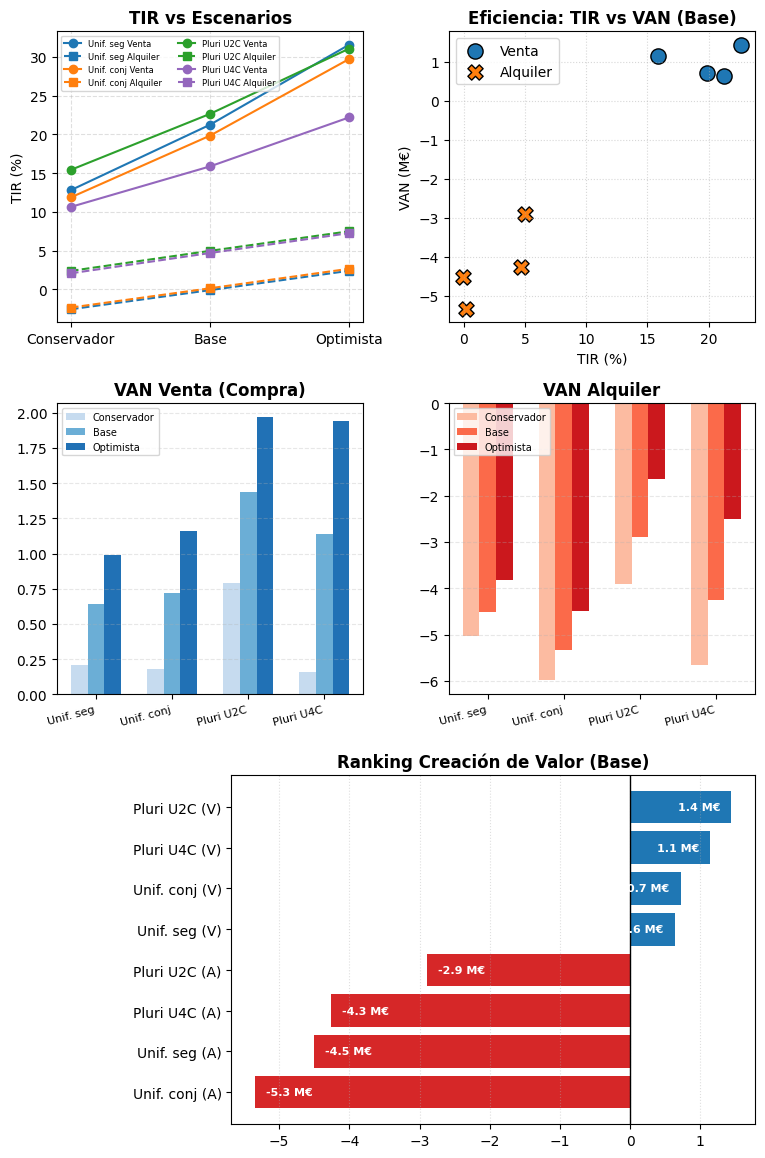

In [9]:
fig = plt.figure(figsize=(8.27, 11.69))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1.2])

# =========================
# AXES
# =========================
ax1 = fig.add_subplot(gs[0, 0])  # TIR vs escenarios
ax2 = fig.add_subplot(gs[0, 1])  # eficiencia

ax3 = fig.add_subplot(gs[1, 0])  # VAN compra
ax4 = fig.add_subplot(gs[1, 1])  # VAN alquiler

ax5 = fig.add_subplot(gs[2, :])  # ranking (full width)

# =========================
# ESCENARIOS
# =========================
esc_x = ["Conservador", "Base", "Optimista"]
x = np.arange(len(esc_x))

# =========================
# Fila 1 - TIR vs escenarios
# =========================
colores_tip = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]
for i, t in enumerate(tipologias):
    ax1.plot(x, tir_venta[i, :], marker='o', linestyle='-',
             color=colores_tip[i], label=f"{t} Venta")
    ax1.plot(x, tir_alquiler[i, :], marker='s', linestyle='--',
             color=colores_tip[i], label=f"{t} Alquiler")

ax1.set_title("TIR vs Escenarios", fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(esc_x)
ax1.set_ylabel("TIR (%)")
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(fontsize=6, ncol=2)

# =========================
# Fila 1 - Eficiencia TIR vs VAN
# =========================
ax2.scatter(tir_venta[:, 1], van_venta[:, 1],
            s=120, label='Venta', edgecolors='k')

ax2.scatter(tir_alquiler[:, 1], van_alquiler[:, 1],
            s=120, marker='X', label='Alquiler', edgecolors='k')

ax2.set_title("Eficiencia: TIR vs VAN (Base)", fontweight='bold')
ax2.set_xlabel("TIR (%)")
ax2.set_ylabel("VAN (M€)")
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend()

# =========================
# Fila 2 - VAN compra
# =========================
x_tip = np.arange(len(tipologias))
width = 0.22

for i in range(3):
    ax3.bar(x_tip + i*width, van_venta[:, i],
            width, label=escenarios[i], color=azules[i])

ax3.set_title("VAN Venta (Compra)", fontweight='bold')
ax3.set_xticks(x_tip + width)
ax3.set_xticklabels(tipologias, rotation=15, ha='right', fontsize=8)
ax3.grid(axis='y', linestyle='--', alpha=0.3)
ax3.legend(fontsize=7, loc='upper left')

# =========================
# Fila 2 - VAN alquiler
# =========================
for i in range(3):
    ax4.bar(x_tip + i*width, van_alquiler[:, i],
            width, label=escenarios[i], color=rojos[i])

ax4.set_title("VAN Alquiler", fontweight='bold')
ax4.set_xticks(x_tip + width)
ax4.set_xticklabels(tipologias, rotation=15, ha='right', fontsize=8)
ax4.grid(axis='y', linestyle='--', alpha=0.3)
ax4.legend(fontsize=7, loc='upper left')

# =========================
# Fila 3 - Ranking
# =========================
total_van = np.concatenate([van_venta[:, 1], van_alquiler[:, 1]])
labels = [f"{t} (V)" for t in tipologias] + [f"{t} (A)" for t in tipologias]

idx = np.argsort(total_van)
vals = total_van[idx]
labs = np.array(labels)[idx]

colors = ["#1f77b4" if v > 0 else "#d62728" for v in vals]

bars = ax5.barh(labs, vals, color=colors)

ax5.axvline(0, color='black', linewidth=1)
ax5.set_title("Ranking Creación de Valor (Base)", fontweight='bold')
ax5.grid(axis='x', linestyle=':', alpha=0.4)

max_abs = np.max(np.abs(vals))
offset = max_abs * 0.03

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

for bar in bars:
    w = bar.get_width()
    x_text = w - offset if w >= 0 else w + offset
    ha = 'right' if w >= 0 else 'left'
    text = ax5.text(x_text, bar.get_y() + bar.get_height()/2,
                    f"{w:.1f} M€",
                    ha=ha, va='center', color='white', fontsize=8, fontweight='bold')
    bar_bbox = bar.get_window_extent(renderer=renderer)
    text_bbox = text.get_window_extent(renderer=renderer)
    if text_bbox.width > (bar_bbox.width - 4):
        text.remove()

# =========================
# FINAL
# =========================
plt.tight_layout()

# Ajuste final: ranking más estrecho y alineado a la derecha
pos = ax5.get_position()
new_width = pos.width * 0.75
new_x0 = pos.x0 + (pos.width - new_width)
ax5.set_position([new_x0, pos.y0, new_width, pos.height])

plt.show()